# **Setup Kaggle API Token di Google Colab**

In [ ]:
from google.colab import files
import shutil, os

uploaded = files.upload()  # pilih file kaggle.json dari laptop

os.makedirs('/root/.config/kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
print("✅ Kaggle API siap!")

Saving kaggle.json to kaggle.json
✅ Kaggle API siap!


# **Download Dataset**

In [ ]:
import os
import shutil

# Paksa kagglehub baca credentials dari kaggle.json
os.environ['KAGGLE_CONFIG_DIR'] = '/root/.config/kaggle'

import kagglehub

path = kagglehub.competition_download('spaceship-titanic')
print("Path to competition files:", path)

shutil.copy(path + '/train.csv', 'train.csv')
shutil.copy(path + '/test.csv', 'test.csv')
shutil.copy(path + '/sample_submission.csv', 'sample_submission.csv')
print("✅ File siap dipakai!")

100%|██████████| 299k/299k [00:00<00:00, 71.7MB/s]

Extracting files...
Path to competition files: /root/.cache/kagglehub/competitions/spaceship-titanic
✅ File siap dipakai!


In [ ]:
import os

files = ['train.csv', 'test.csv', 'sample_submission.csv']
for f in files:
    if os.path.exists(f):
        print(f"✅ {f} — ada")
    else:
        print(f"❌ {f} — TIDAK ADA")

✅ train.csv — ada
✅ test.csv — ada
✅ sample_submission.csv — ada


# **Import Library**

In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [ ]:
# ─────────────────────────────────────────
# 1. Basic Library
# ─────────────────────────────────────────
import os
import random
import warnings

import numpy as np
import pandas as pd


# ─────────────────────────────────────────
# 2. Visualization
# ─────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns


# ─────────────────────────────────────────
# 3. Reproducibility / Stability
# ─────────────────────────────────────────
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings("ignore")


# ─────────────────────────────────────────
# 4. Data Split & Validation
# ─────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)


# ─────────────────────────────────────────
# 5. Preprocessing
# ─────────────────────────────────────────
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    RobustScaler
)

from sklearn.impute import SimpleImputer


# ─────────────────────────────────────────
# 6. Classical Machine Learning Models
# ─────────────────────────────────────────
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    VotingClassifier
)

import lightgbm as lgb
import xgboost as xgb


# ─────────────────────────────────────────
# 7. Evaluation Metrics
# ─────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# ─────────────────────────────────────────
# 8. Utility
# ─────────────────────────────────────────
from sklearn.base import clone


# ─────────────────────────────────────────
# 9. Display Setting
# ─────────────────────────────────────────
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

# **Load Dataset**

In [ ]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print("Shape Train:", train_df.shape)
print("Shape Test :", test_df.shape)

print("\n--- Baris Pertama Train ---")
train_df.head()

Shape Train: (8693, 14)
Shape Test : (4277, 13)

--- Baris Pertama Train ---


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [ ]:
sample_submission = pd.read_csv('sample_submission.csv')

print("Shape Sample Submission:", sample_submission.shape)
sample_submission.head()

Shape Sample Submission: (4277, 2)


,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,False
4,0023_01,False


# **EDA**

In [ ]:
print("=" * 50)
print("INFORMASI UMUM DATASET")
print("=" * 50)

# Info tipe data dan jumlah non-null
print("\n--- INFO DATASET ---")
train_df.info()

INFORMASI UMUM DATASET

--- INFO DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [ ]:
# Statistik deskriptif kolom numerik
print("\n--- STATISTIK DESKRIPTIF ---")
train_df.describe()


--- STATISTIK DESKRIPTIF ---


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [ ]:
# Cek tipe data lebih detail
print("\n--- TIPE DATA ---")
print(train_df.dtypes)

print("\n--- JUMLAH NILAI UNIK TIAP KOLOM ---")
print(train_df.nunique())


--- TIPE DATA ---
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

--- JUMLAH NILAI UNIK TIAP KOLOM ---
PassengerId     8693
HomePlanet         3
CryoSleep          2
Cabin           6560
Destination        3
Age               80
VIP                2
RoomService     1273
FoodCourt       1507
ShoppingMall    1115
Spa             1327
VRDeck          1306
Name            8473
Transported        2
dtype: int64


In [ ]:
# Cek duplikat
print("\n--- CEK DATA DUPLIKAT ---")
duplicate_rows_train = train_df.duplicated().sum()
duplicate_rows_test = test_df.duplicated().sum()

print("Jumlah duplikasi seluruh baris pada train:", duplicate_rows_train)
print("Jumlah duplikasi seluruh baris pada test :", duplicate_rows_test)


--- CEK DATA DUPLIKAT ---
Jumlah duplikasi seluruh baris pada train: 0
Jumlah duplikasi seluruh baris pada test : 0


In [ ]:
# Cek duplikat Semua
print("===== CEK DUPLIKASI TRAIN =====")
print("Duplikasi seluruh baris:", train_df.duplicated().sum())
print("Duplikasi PassengerId:", train_df['PassengerId'].duplicated().sum())
print("Jumlah PassengerId unik:", train_df['PassengerId'].nunique())
print("Jumlah baris train:", len(train_df))

print("\n===== CEK DUPLIKASI TEST =====")
print("Duplikasi seluruh baris:", test_df.duplicated().sum())
print("Duplikasi PassengerId:", test_df['PassengerId'].duplicated().sum())
print("Jumlah PassengerId unik:", test_df['PassengerId'].nunique())
print("Jumlah baris test:", len(test_df))

print("\n===== CEK OVERLAP TRAIN-TEST =====")
overlap_passenger = set(train_df['PassengerId']).intersection(set(test_df['PassengerId']))
print("PassengerId yang muncul di train dan test:", len(overlap_passenger))

print("\n===== CEK KOLOM KHUSUS =====")
print("Duplikasi Name train:", train_df['Name'].duplicated().sum())
print("Duplikasi Cabin train:", train_df['Cabin'].duplicated().sum())

train_df['GroupId'] = train_df['PassengerId'].str.split('_').str[0]
group_counts = train_df['GroupId'].value_counts()

print("\nJumlah GroupId unik:", train_df['GroupId'].nunique())
print("Jumlah grup dengan lebih dari 1 anggota:", (group_counts > 1).sum())

===== CEK DUPLIKASI TRAIN =====
Duplikasi seluruh baris: 0
Duplikasi PassengerId: 0
Jumlah PassengerId unik: 8693
Jumlah baris train: 8693

===== CEK DUPLIKASI TEST =====
Duplikasi seluruh baris: 0
Duplikasi PassengerId: 0
Jumlah PassengerId unik: 4277
Jumlah baris test: 4277

===== CEK OVERLAP TRAIN-TEST =====
PassengerId yang muncul di train dan test: 0

===== CEK KOLOM KHUSUS =====
Duplikasi Name train: 219
Duplikasi Cabin train: 2132

Jumlah GroupId unik: 6217
Jumlah grup dengan lebih dari 1 anggota: 1412


In [ ]:
# Hitung jumlah dan persentase missing value
missing_count = train_df.isnull().sum()
missing_percentage = (train_df.isnull().mean() * 100).round(2)

missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percentage
}).sort_values(by='Missing Percentage (%)', ascending=False)

missing_table

,Missing Count,Missing Percentage (%)
CryoSleep,217,2.50
ShoppingMall,208,2.39
VIP,203,2.34
HomePlanet,201,2.31
Name,200,2.30
Cabin,199,2.29
VRDeck,188,2.16
Spa,183,2.11
FoodCourt,183,2.11
Destination,182,2.09


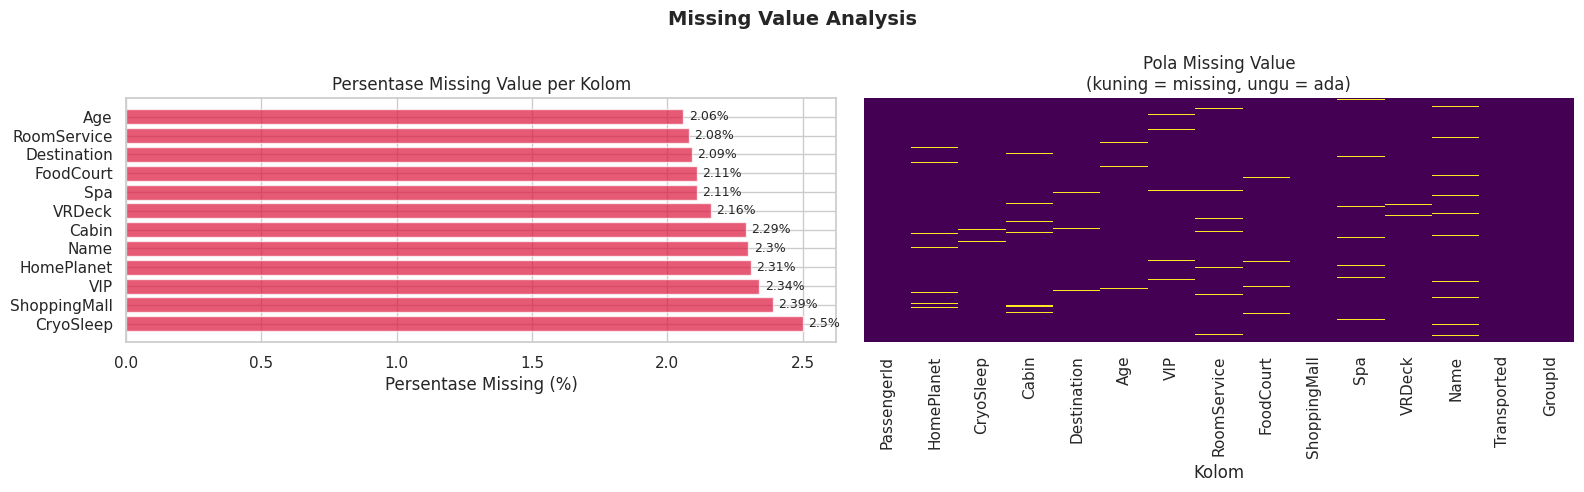

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi missing value
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Missing Value Analysis', fontsize=14, fontweight='bold')

# Bar chart persentase missing
missing_plot = missing_table[missing_table['Missing Count'] > 0]
axes[0].barh(missing_plot.index, missing_plot['Missing Percentage (%)'], color='crimson', alpha=0.7)
axes[0].set_xlabel('Persentase Missing (%)')
axes[0].set_title('Persentase Missing Value per Kolom')
for i, (val) in enumerate(missing_plot['Missing Percentage (%)']):
    axes[0].text(val + 0.02, i, f'{val}%', va='center', fontsize=9)

# Heatmap missing value
sns.heatmap(train_df.isnull(),
            yticklabels=False,
            cbar=False,
            cmap='viridis',
            ax=axes[1])
axes[1].set_title('Pola Missing Value\n(kuning = missing, ungu = ada)')
axes[1].set_xlabel('Kolom')

plt.tight_layout()
plt.show()

In [ ]:
# Cek apakah missing value terjadi bersamaan
print("\n--- APAKAH MISSING TERJADI BERSAMAAN? ---")
print("Baris dengan lebih dari 3 kolom kosong:")
baris_banyak_missing = train_df[train_df.isnull().sum(axis=1) > 3]
print(f"Jumlah: {len(baris_banyak_missing)} baris")
print(f"Persentase: {len(baris_banyak_missing)/len(train_df)*100:.2f}%")


--- APAKAH MISSING TERJADI BERSAMAAN? ---
Baris dengan lebih dari 3 kolom kosong:
Jumlah: 0 baris
Persentase: 0.00%


In [ ]:
# Cek missing value pada test
missing_test = pd.DataFrame({
    'Missing Count': test_df.isnull().sum(),
    'Missing Percentage (%)': (test_df.isnull().mean() * 100).round(2)
}).sort_values(by='Missing Percentage (%)', ascending=False)

display(missing_test)

,Missing Count,Missing Percentage (%)
FoodCourt,106,2.48
Spa,101,2.36
Cabin,100,2.34
ShoppingMall,98,2.29
Name,94,2.20
VIP,93,2.17
CryoSleep,93,2.17
Destination,92,2.15
Age,91,2.13
HomePlanet,87,2.03


In [ ]:
# Hitung distribusi
print("--- DISTRIBUSI TARGET (Transported) ---")
target_count = train_df['Transported'].value_counts()
target_pct   = train_df['Transported'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Jumlah'       : target_count,
    'Persentase (%)': target_pct.round(2)
})
print(target_summary)

--- DISTRIBUSI TARGET (Transported) ---
             Jumlah  Persentase (%)
Transported                        
True           4378           50.36
False          4315           49.64


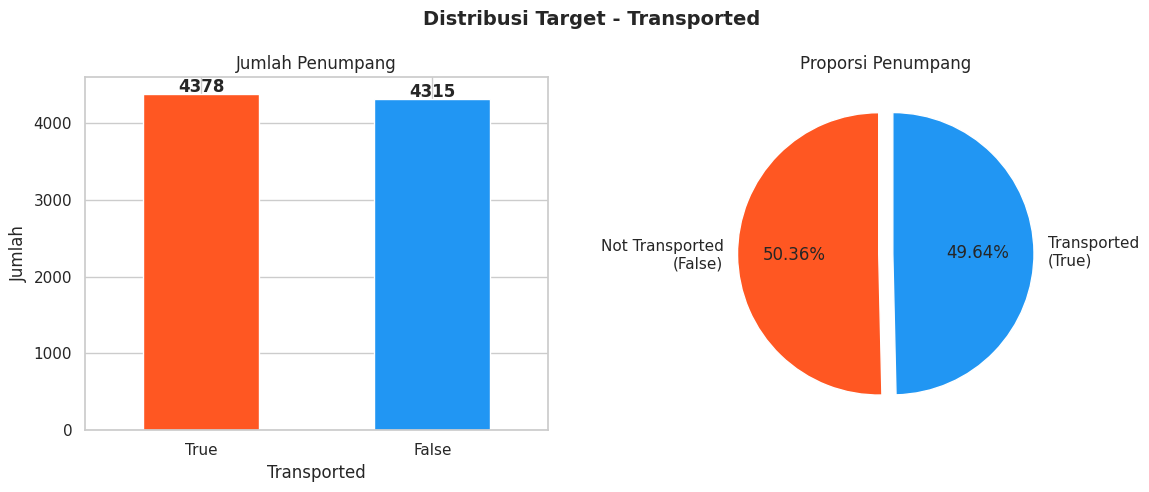

In [ ]:
# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribusi Target - Transported', fontsize=14, fontweight='bold')

# Bar chart
colors = ['#FF5722', '#2196F3']
target_count.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Jumlah Penumpang')
axes[0].set_xlabel('Transported')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(rotation=0)
for i, v in enumerate(target_count):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_count,
            labels=['Not Transported\n(False)', 'Transported\n(True)'],
            colors=colors,
            autopct='%1.2f%%',
            startangle=90,
            explode=(0.05, 0.05))
axes[1].set_title('Proporsi Penumpang')

plt.tight_layout()
plt.show()

In [ ]:
# Kesimpulan balance
total = len(train_df)
true_pct  = (train_df['Transported'].sum() / total * 100)
false_pct = 100 - true_pct

print(f"\nTransported True  : {true_pct:.2f}%")
print(f"Transported False : {false_pct:.2f}%")

if abs(true_pct - false_pct) < 10:
    print("\n Dataset SEIMBANG — tidak perlu teknik khusus seperti SMOTE")
else:
    print("\n Dataset TIDAK SEIMBANG — perlu penanganan khusus")


Transported True  : 50.36%
Transported False : 49.64%

 Dataset SEIMBANG — tidak perlu teknik khusus seperti SMOTE


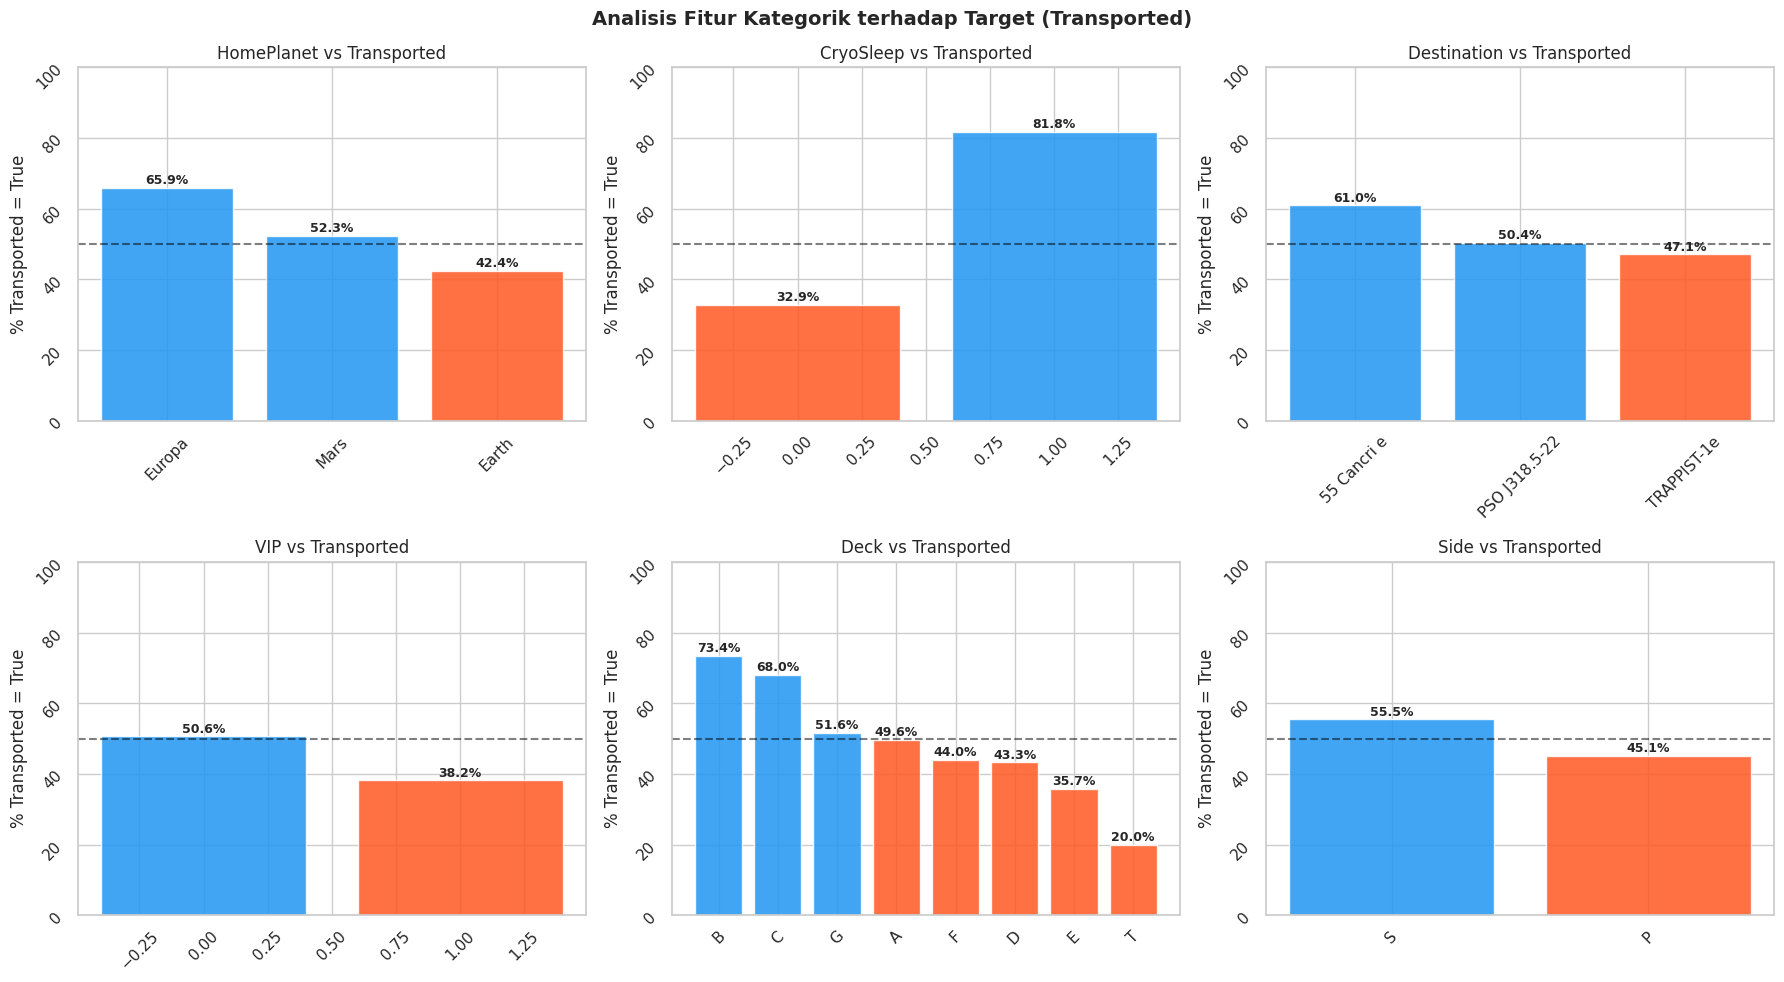

In [ ]:
# ANALISIS FITUR KATEGORIK TERHADAP TARGET
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Analisis Fitur Kategorik terhadap Target (Transported)',
             fontsize=14, fontweight='bold')

cat_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

# Sementara ekstrak Deck dan Side dari Cabin dulu untuk EDA
train_df['Deck'] = train_df['Cabin'].str.split('/').str[0]
train_df['Side'] = train_df['Cabin'].str.split('/').str[2]

for i, col in enumerate(cat_features):
    ax = axes[i//3][i%3]

    # Hitung persentase Transported=True per kategori
    pct = train_df.groupby(col)['Transported'].mean() * 100
    pct = pct.sort_values(ascending=False)

    bars = ax.bar(pct.index, pct.values,
                  color=['#2196F3' if v > 50 else '#FF5722' for v in pct.values],
                  edgecolor='white', alpha=0.85)

    ax.axhline(y=50, color='black', linestyle='--', alpha=0.5, label='50% line')
    ax.set_title(f'{col} vs Transported')
    ax.set_ylabel('% Transported = True')
    ax.set_ylim(0, 100)
    ax.tick_params(rotation=45)

    # Tambahkan angka di atas bar
    for bar, val in zip(bars, pct.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 1,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Detail angka per kategori
print("=" * 50)
for col in cat_features:
    print(f"\n--- {col} ---")
    summary = train_df.groupby(col)['Transported'].agg(['mean', 'count'])
    summary.columns = ['% Transported', 'Jumlah']
    summary['% Transported'] = (summary['% Transported'] * 100).round(2)
    print(summary)
    print()


--- HomePlanet ---
            % Transported  Jumlah
HomePlanet                       
Earth               42.39    4602
Europa              65.88    2131
Mars                52.30    1759


--- CryoSleep ---
           % Transported  Jumlah
CryoSleep                       
False              32.89    5439
True               81.76    3037


--- Destination ---
               % Transported  Jumlah
Destination                         
55 Cancri e            61.00    1800
PSO J318.5-22          50.38     796
TRAPPIST-1e            47.12    5915


--- VIP ---
       % Transported  Jumlah
VIP                         
False          50.63    8291
True           38.19     199


--- Deck ---
      % Transported  Jumlah
Deck                       
A             49.61     256
B             73.43     779
C             68.01     747
D             43.31     478
E             35.73     876
F             43.99    2794
G             51.62    2559
T             20.00       5


--- Side ---
      % Tra

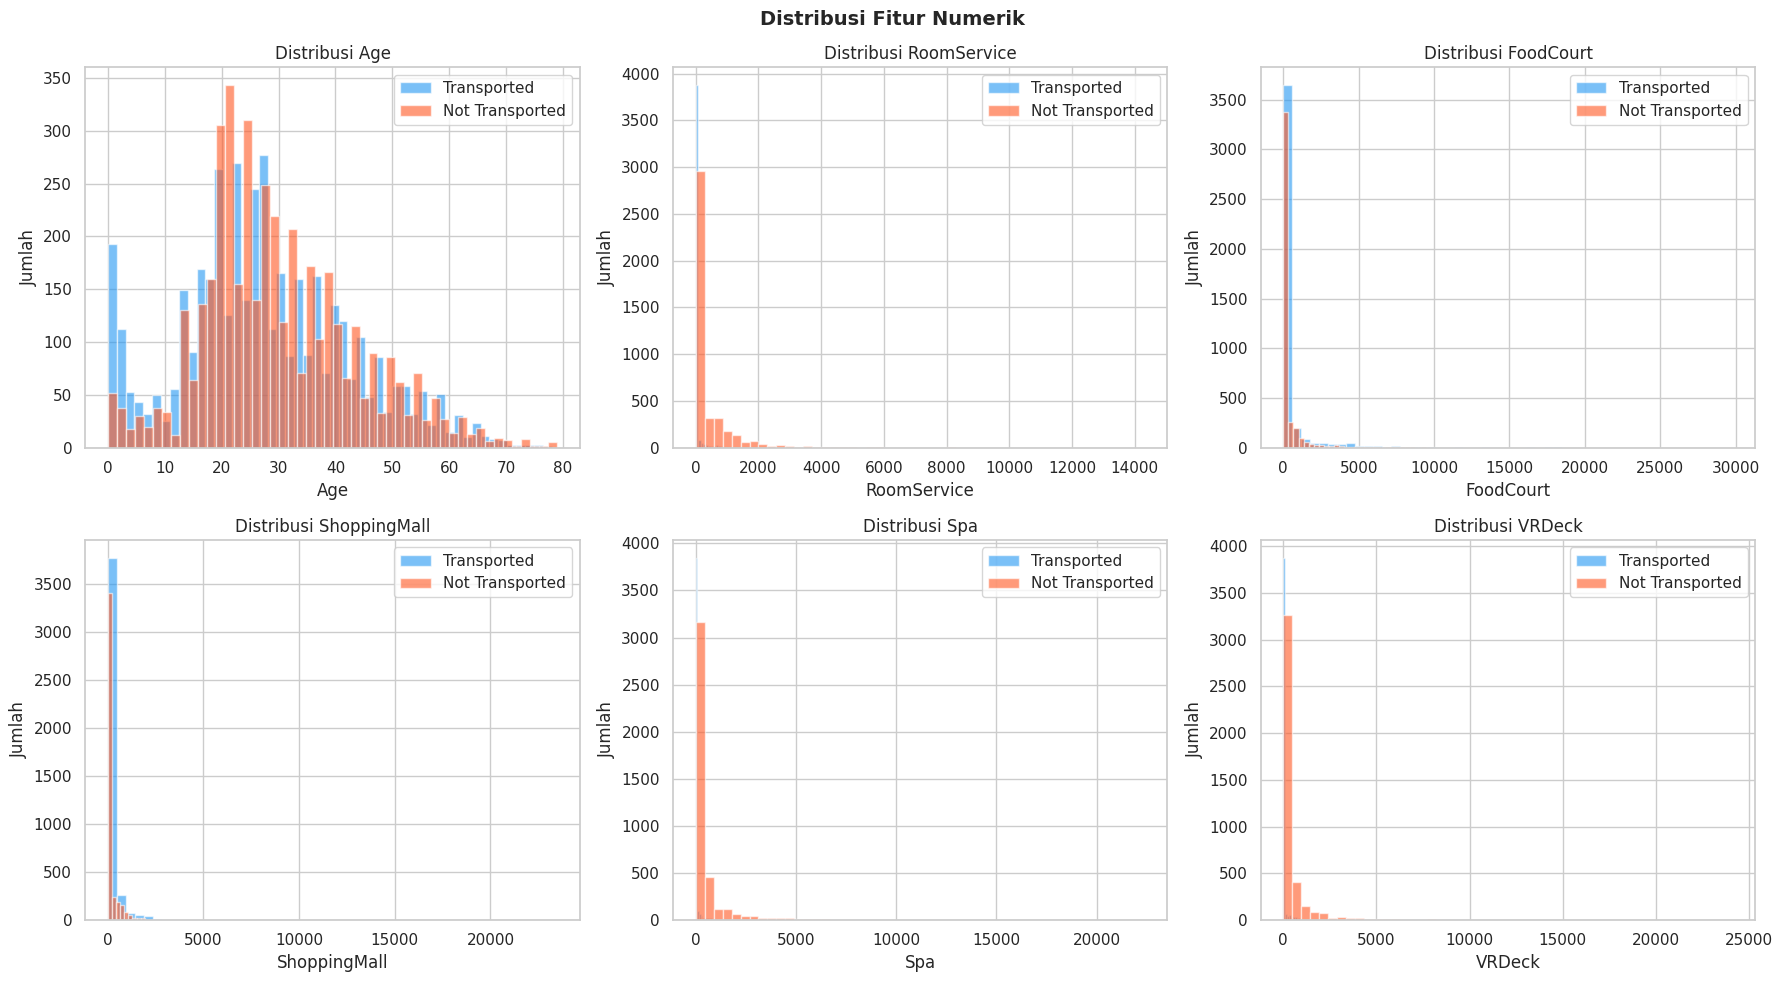

In [ ]:
# ANALISIS FITUR NUMERIK TERHADAP TARGET
num_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 8.1 Distribusi fitur numerik
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')

for i, col in enumerate(num_features):
    ax = axes[i//3][i%3]

    # Plot histogram per kelas target
    train_df[train_df['Transported']==True][col].dropna()\
        .hist(bins=50, ax=ax, alpha=0.6, color='#2196F3', label='Transported')
    train_df[train_df['Transported']==False][col].dropna()\
        .hist(bins=50, ax=ax, alpha=0.6, color='#FF5722', label='Not Transported')

    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Jumlah')
    ax.legend()

plt.tight_layout()
plt.show()

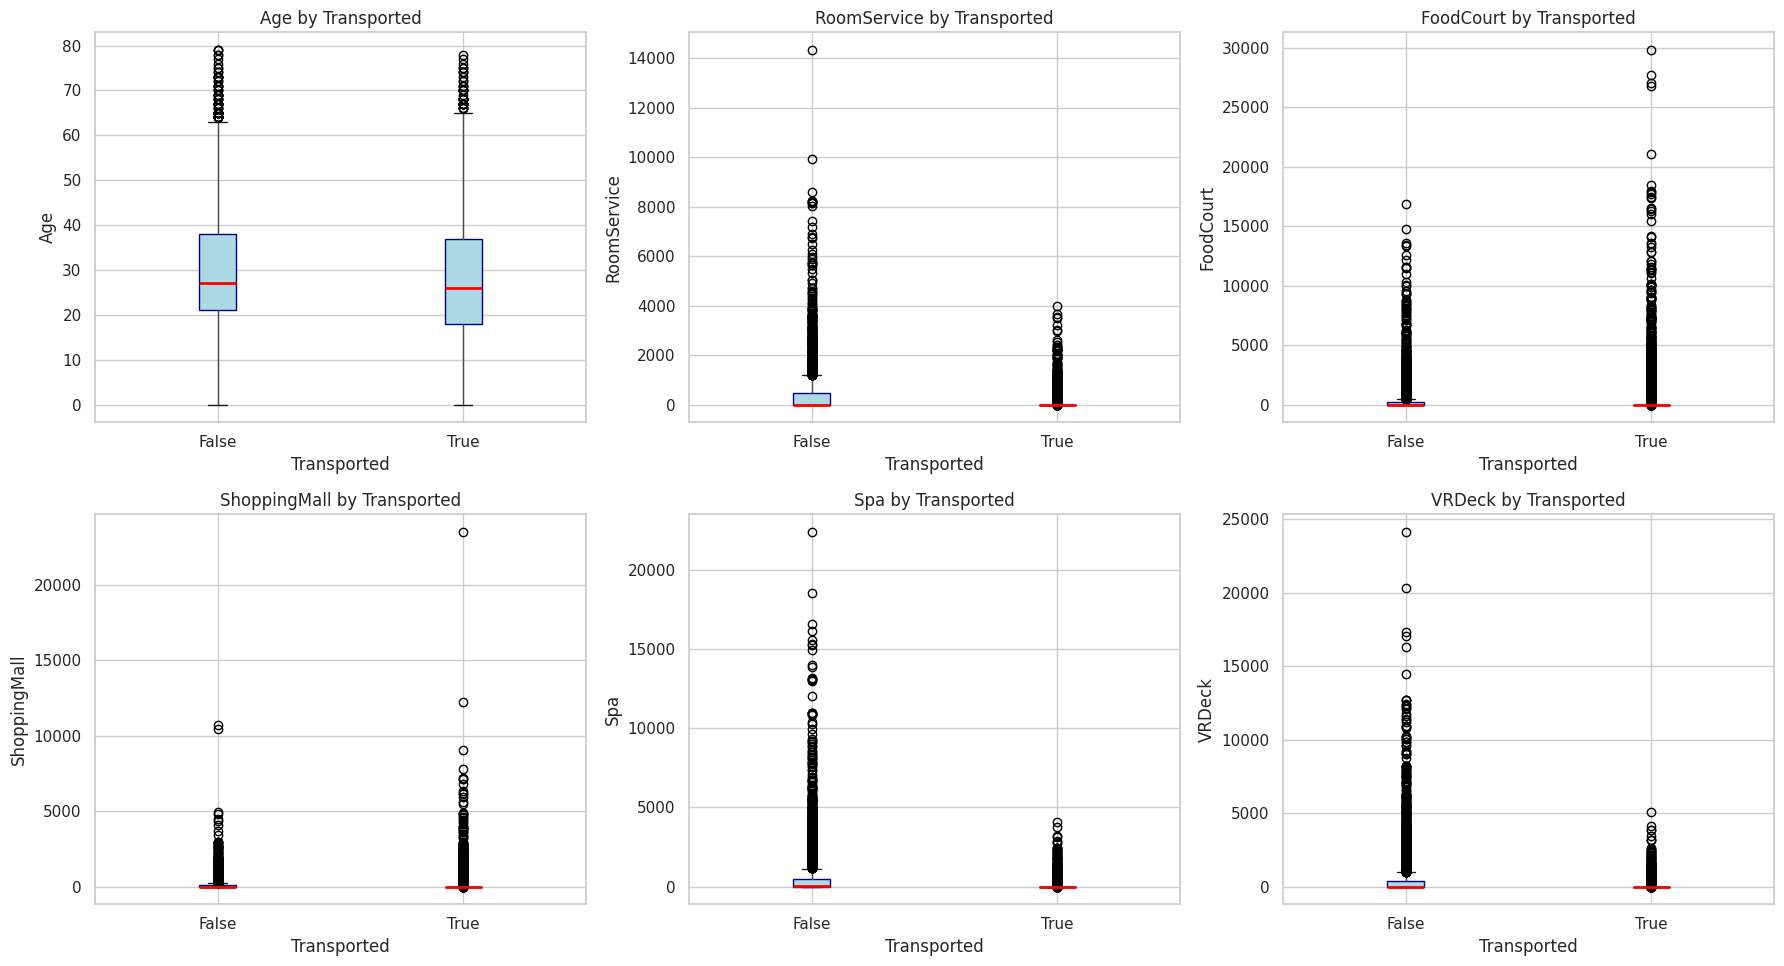

In [ ]:
# Boxplot untuk deteksi outlier
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Boxplot Fitur Numerik (Deteksi Outlier)',
             fontsize=14, fontweight='bold')

for i, col in enumerate(num_features):
    ax = axes[i//3][i%3]

    train_df.boxplot(column=col, by='Transported', ax=ax,
                     patch_artist=True,
                     boxprops=dict(facecolor='lightblue', color='navy'),
                     medianprops=dict(color='red', linewidth=2))

    ax.set_title(f'{col} by Transported')
    ax.set_xlabel('Transported')
    ax.set_ylabel(col)

plt.suptitle('')  # hapus judul otomatis dari boxplot
plt.tight_layout()
plt.show()

In [ ]:
# Persentase nilai NOL pada kolom spending
print("--- PERSENTASE NILAI 0 PADA KOLOM SPENDING ---")
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

for col in spending_cols:
    pct_zero = (train_df[col] == 0).sum() / len(train_df) * 100
    print(f"{col:15s} : {pct_zero:.1f}% bernilai 0")

--- PERSENTASE NILAI 0 PADA KOLOM SPENDING ---
RoomService     : 64.2% bernilai 0
FoodCourt       : 62.8% bernilai 0
ShoppingMall    : 64.3% bernilai 0
Spa             : 61.2% bernilai 0
VRDeck          : 63.2% bernilai 0


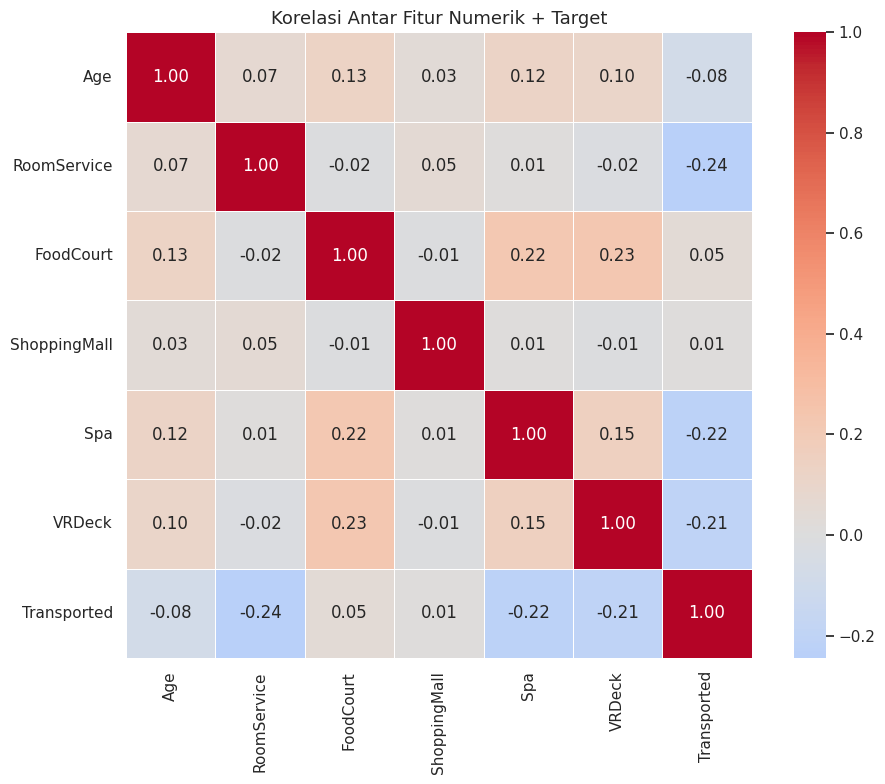


Korelasi dengan Target (Transported):
Transported     1.000000
FoodCourt       0.046566
ShoppingMall    0.010141
Age            -0.075026
VRDeck         -0.207075
Spa            -0.221131
RoomService    -0.244611
Name: Transported, dtype: float64


In [ ]:
# Korelasi antar fitur numerik
fig, ax = plt.subplots(figsize=(10, 8))

# Ubah Transported ke angka untuk korelasi
corr_df = train_df[num_features + ['Transported']].copy()
corr_df['Transported'] = corr_df['Transported'].astype(int)

corr_matrix = corr_df.corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            ax=ax,
            linewidths=0.5)

ax.set_title('Korelasi Antar Fitur Numerik + Target', fontsize=13)
plt.tight_layout()
plt.show()

print("\nKorelasi dengan Target (Transported):")
print(corr_matrix['Transported'].sort_values(ascending=False))

In [ ]:
# Statistik per kelas target
print("\n--- RATA-RATA SPENDING: Transported vs Not Transported ---")
print(train_df.groupby('Transported')[spending_cols + ['Age']].mean().round(2))


--- RATA-RATA SPENDING: Transported vs Not Transported ---
             RoomService  FoodCourt  ShoppingMall     Spa  VRDeck    Age
Transported                                                             
False             389.27     382.62        167.57  564.38  543.63  29.92
True               63.10     532.69        179.83   61.68   69.15  27.75


In [ ]:
# Feature Engineering
# Train + Test diproses bersama agar konsisten

def feature_engineering(train_df: pd.DataFrame, test_df: pd.DataFrame):
    train = train_df.copy()
    test = test_df.copy()

    train["_is_train"] = 1
    test["_is_train"] = 0

    combined = pd.concat([train, test], axis=0, ignore_index=True)

    # ─────────────────────────────────────────
    # 1. PassengerId Features
    # ─────────────────────────────────────────
    pid_split = combined["PassengerId"].str.split("_", expand=True)

    combined["Group"] = pid_split[0].astype(int)
    combined["Member"] = pid_split[1].astype(int)

    combined["GroupSize"] = combined.groupby("Group")["PassengerId"].transform("count")
    combined["IsAlone"] = (combined["GroupSize"] == 1).astype(int)

    # ─────────────────────────────────────────
    # 2. Cabin Features
    # ─────────────────────────────────────────
    cabin_split = combined["Cabin"].str.split("/", expand=True)

    combined["Deck"] = cabin_split[0]
    combined["CabinNum"] = pd.to_numeric(cabin_split[1], errors="coerce")
    combined["Side"] = cabin_split[2]

    combined["CabinKnown"] = combined["Cabin"].notna().astype(int)

    combined["CabinNumBin"] = pd.cut(
        combined["CabinNum"],
        bins=[-1, 300, 600, 900, 1200, 1500, 2000],
        labels=["0_300", "301_600", "601_900", "901_1200", "1201_1500", "1501_2000"]
    )

    combined["CabinNumMod10"] = combined["CabinNum"] % 10

    # ─────────────────────────────────────────
    # 3. Spending Features
    # ─────────────────────────────────────────
    spending_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

    for col in spending_cols:
        combined[col] = pd.to_numeric(combined[col], errors="coerce")

    spending_filled = combined[spending_cols].fillna(0)

    combined["TotalSpending"] = spending_filled.sum(axis=1)
    combined["LuxurySpending"] = spending_filled["Spa"] + spending_filled["VRDeck"]
    combined["FoodSpending"] = (
        spending_filled["RoomService"]
        + spending_filled["FoodCourt"]
        + spending_filled["ShoppingMall"]
    )

    combined["HasSpending"] = (combined["TotalSpending"] > 0).astype(int)
    combined["NoSpending"] = (combined["TotalSpending"] == 0).astype(int)
    combined["SpendingMissingCount"] = combined[spending_cols].isna().sum(axis=1)

    for col in spending_cols:
        combined[f"{col}_log"] = np.log1p(combined[col].fillna(0))

    combined["TotalSpending_log"] = np.log1p(combined["TotalSpending"])
    combined["LuxurySpending_log"] = np.log1p(combined["LuxurySpending"])
    combined["FoodSpending_log"] = np.log1p(combined["FoodSpending"])

    # ─────────────────────────────────────────
    # 4. Age Features
    # ─────────────────────────────────────────
    combined["Age"] = pd.to_numeric(combined["Age"], errors="coerce")
    combined["AgeMissing"] = combined["Age"].isna().astype(int)

    combined["AgeGroup"] = pd.cut(
        combined["Age"],
        bins=[-1, 12, 17, 30, 50, 200],
        labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"]
    )

    # ─────────────────────────────────────────
    # 5. Logic / Interaction Features
    # ─────────────────────────────────────────
    combined["CryoInconsistency"] = (
        (combined["CryoSleep"] == True) & (combined["TotalSpending"] > 0)
    ).astype(int)

    def safe_str(series):
        return series.astype("object").where(series.notna(), "Missing").astype(str)

    combined["HomePlanet_Destination"] = (
        safe_str(combined["HomePlanet"]) + "_" + safe_str(combined["Destination"])
    )

    combined["Deck_Side"] = (
        safe_str(combined["Deck"]) + "_" + safe_str(combined["Side"])
    )

    combined["Cryo_HasSpending"] = (
        safe_str(combined["CryoSleep"]) + "_" + combined["HasSpending"].astype(str)
    )

    combined["VIP_HasSpending"] = (
        safe_str(combined["VIP"]) + "_" + combined["HasSpending"].astype(str)
    )

    # ─────────────────────────────────────────
    # 6. Drop Unused Columns
    # ─────────────────────────────────────────
    combined.drop(columns=["Cabin", "Name"], inplace=True, errors="ignore")

    # Split kembali
    train_eng = combined[combined["_is_train"] == 1].drop(columns=["_is_train"])
    test_eng = combined[combined["_is_train"] == 0].drop(
        columns=["_is_train", "Transported"],
        errors="ignore"
    )

    return train_eng, test_eng


train_eng, test_eng = feature_engineering(train_df, test_df)

print(f"Shape train setelah FE : {train_eng.shape}")
print(f"Shape test setelah FE  : {test_eng.shape}")

Shape train setelah FE : (8693, 44)
Shape test setelah FE  : (4277, 43)


In [ ]:
# CEK PERBEDAAN KOLOM TRAIN DAN TEST
train_cols = set(train_eng.columns)
test_cols = set(test_eng.columns)

print("Kolom yang ada di train tapi tidak ada di test:")
print(train_cols - test_cols)

print("\nKolom yang ada di test tapi tidak ada di train:")
print(test_cols - train_cols)

Kolom yang ada di train tapi tidak ada di test:
{'Transported'}

Kolom yang ada di test tapi tidak ada di train:
set()


In [ ]:
# Cek hasil feature engineering
print("\n--- 5 Baris Pertama Setelah Feature Engineering ---")
train_eng.head()


--- 5 Baris Pertama Setelah Feature Engineering ---


,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupId,Deck,Side,Group,Member,GroupSize,IsAlone,CabinNum,CabinKnown,CabinNumBin,CabinNumMod10,TotalSpending,LuxurySpending,FoodSpending,HasSpending,NoSpending,SpendingMissingCount,RoomService_log,FoodCourt_log,ShoppingMall_log,Spa_log,VRDeck_log,TotalSpending_log,LuxurySpending_log,FoodSpending_log,AgeMissing,AgeGroup,CryoInconsistency,HomePlanet_Destination,Deck_Side,Cryo_HasSpending,VIP_HasSpending
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,0001,B,P,1,1,1,1,0.0,1,0_300,0.0,0.0,0.0,0.0,0,1,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,Adult,0,Europa_TRAPPIST-1e,B_P,False_0,False_0
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,0002,F,S,2,1,1,1,0.0,1,0_300,0.0,736.0,593.0,143.0,1,0,0,4.700480,2.302585,3.258097,6.309918,3.806662,6.602588,6.386879,4.969813,0,YoungAdult,0,Earth_TRAPPIST-1e,F_S,False_1,False_1
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,0003,A,S,3,1,2,0,0.0,1,0_300,0.0,10383.0,6764.0,3619.0,1,0,0,3.784190,8.182280,0.000000,8.812248,3.912023,9.248021,8.819518,8.194229,0,Senior,0,Europa_TRAPPIST-1e,A_S,False_1,True_1
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,0003,A,S,3,2,2,0,0.0,1,0_300,0.0,5176.0,3522.0,1654.0,1,0,0,0.000000,7.157735,5.918894,8.110728,5.267858,8.551981,8.167068,7.411556,0,Adult,0,Europa_TRAPPIST-1e,A_S,False_1,False_1
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,0004,F,S,4,1,1,1,1.0,1,0_300,1.0,1091.0,567.0,524.0,1,0,0,5.717028,4.262680,5.023881,6.338594,1.098612,6.995766,6.342121,6.263398,0,Teen,0,Earth_TRAPPIST-1e,F_S,False_1,False_1


In [ ]:
# CEK MISSING VALUE SETELAH FEATURE ENGINEERING
missing_train_eng = pd.DataFrame({
    'Missing Count': train_eng.isnull().sum(),
    'Missing Percentage (%)': (train_eng.isnull().mean() * 100).round(2)
}).sort_values(by='Missing Percentage (%)', ascending=False)

missing_test_eng = pd.DataFrame({
    'Missing Count': test_eng.isnull().sum(),
    'Missing Percentage (%)': (test_eng.isnull().mean() * 100).round(2)
}).sort_values(by='Missing Percentage (%)', ascending=False)

print("Missing value train setelah feature engineering:")
display(missing_train_eng.head(30))

print("\nMissing value test setelah feature engineering:")
display(missing_test_eng.head(30))

Missing value train setelah feature engineering:


,Missing Count,Missing Percentage (%)
CryoSleep,217,2.50
ShoppingMall,208,2.39
VIP,203,2.34
HomePlanet,201,2.31
CabinNumBin,199,2.29
CabinNum,199,2.29
Side,199,2.29
CabinNumMod10,199,2.29
Deck,199,2.29
VRDeck,188,2.16



Missing value test setelah feature engineering:


,Missing Count,Missing Percentage (%)
GroupId,4277,100.00
FoodCourt,106,2.48
Spa,101,2.36
CabinNum,100,2.34
Side,100,2.34
CabinNumBin,100,2.34
CabinNumMod10,100,2.34
Deck,100,2.34
ShoppingMall,98,2.29
CryoSleep,93,2.17


In [ ]:
# Pilih Fitur dan Siapkan X / y
FEATURES = [
    # Original features
    "HomePlanet",
    "CryoSleep",
    "Destination",
    "Age",
    "VIP",

    # PassengerId features
    "Group",
    "Member",
    "GroupSize",
    "IsAlone",

    # Cabin features
    "Deck",
    "Side",
    "CabinNum",
    "CabinKnown",
    "CabinNumBin",
    "CabinNumMod10",

    # Spending log features
    "RoomService_log",
    "FoodCourt_log",
    "ShoppingMall_log",
    "Spa_log",
    "VRDeck_log",
    "TotalSpending_log",
    "LuxurySpending_log",
    "FoodSpending_log",

    # Spending flags
    "HasSpending",
    "NoSpending",
    "SpendingMissingCount",

    # Age features
    "AgeMissing",
    "AgeGroup",

    # Interaction features
    "CryoInconsistency",
    "HomePlanet_Destination",
    "Deck_Side",
    "Cryo_HasSpending",
    "VIP_HasSpending",
]

TARGET = "Transported"

X = train_eng[FEATURES].copy()
y = train_eng[TARGET].astype(int).copy()
X_test_raw = test_eng[FEATURES].copy()

print(f"X          : {X.shape}")
print(f"y          : {y.shape}")
print(f"X_test_raw : {X_test_raw.shape}")

X.head()

X          : (8693, 33)
y          : (8693,)
X_test_raw : (4277, 33)


,HomePlanet,CryoSleep,Destination,Age,VIP,Group,Member,GroupSize,IsAlone,Deck,Side,CabinNum,CabinKnown,CabinNumBin,CabinNumMod10,RoomService_log,FoodCourt_log,ShoppingMall_log,Spa_log,VRDeck_log,TotalSpending_log,LuxurySpending_log,FoodSpending_log,HasSpending,NoSpending,SpendingMissingCount,AgeMissing,AgeGroup,CryoInconsistency,HomePlanet_Destination,Deck_Side,Cryo_HasSpending,VIP_HasSpending
0,Europa,False,TRAPPIST-1e,39.0,False,1,1,1,1,B,P,0.0,1,0_300,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,1,0,0,Adult,0,Europa_TRAPPIST-1e,B_P,False_0,False_0
1,Earth,False,TRAPPIST-1e,24.0,False,2,1,1,1,F,S,0.0,1,0_300,0.0,4.700480,2.302585,3.258097,6.309918,3.806662,6.602588,6.386879,4.969813,1,0,0,0,YoungAdult,0,Earth_TRAPPIST-1e,F_S,False_1,False_1
2,Europa,False,TRAPPIST-1e,58.0,True,3,1,2,0,A,S,0.0,1,0_300,0.0,3.784190,8.182280,0.000000,8.812248,3.912023,9.248021,8.819518,8.194229,1,0,0,0,Senior,0,Europa_TRAPPIST-1e,A_S,False_1,True_1
3,Europa,False,TRAPPIST-1e,33.0,False,3,2,2,0,A,S,0.0,1,0_300,0.0,0.000000,7.157735,5.918894,8.110728,5.267858,8.551981,8.167068,7.411556,1,0,0,0,Adult,0,Europa_TRAPPIST-1e,A_S,False_1,False_1
4,Earth,False,TRAPPIST-1e,16.0,False,4,1,1,1,F,S,1.0,1,0_300,1.0,5.717028,4.262680,5.023881,6.338594,1.098612,6.995766,6.342121,6.263398,1,0,0,0,Teen,0,Earth_TRAPPIST-1e,F_S,False_1,False_1


In [ ]:
# CEK FITUR FINAL, TARGET, DAN MISSING VALUE
# 1. Cek apakah kolom train dan test sama

print("\n" + "=" * 60)
print("CEK KESESUAIAN KOLOM TRAIN DAN TEST")
print("=" * 60)

same_columns = list(X.columns) == list(X_test_raw.columns)

if same_columns:
    print("✅ Kolom X dan X_test_raw sudah sama dan urutannya sesuai.")
else:
    print("❌ Kolom X dan X_test_raw berbeda!")

    train_only = set(X.columns) - set(X_test_raw.columns)
    test_only = set(X_test_raw.columns) - set(X.columns)

    print("\nKolom hanya ada di X:")
    print(train_only)

    print("\nKolom hanya ada di X_test_raw:")
    print(test_only)


# 2. Cek missing value X dan X_test_raw
print("\n" + "=" * 60)
print("CEK MISSING VALUE FITUR FINAL")
print("=" * 60)

missing_report = pd.DataFrame({
    "Missing X": X.isnull().sum(),
    "Missing X (%)": (X.isnull().mean() * 100).round(2),
    "Missing X_test_raw": X_test_raw.isnull().sum(),
    "Missing X_test_raw (%)": (X_test_raw.isnull().mean() * 100).round(2)
})

missing_report = missing_report.sort_values(
    by=["Missing X", "Missing X_test_raw"],
    ascending=False
)

display(missing_report)

missing_only = missing_report[
    (missing_report["Missing X"] > 0) |
    (missing_report["Missing X_test_raw"] > 0)
]

print("\nFitur yang memiliki missing value:")

if len(missing_only) > 0:
    display(missing_only)
else:
    print("✅ Tidak ada missing value pada fitur final.")


# 3. Cek target y
print("\n" + "=" * 60)
print("CEK TARGET")
print("=" * 60)

print(f"Missing value pada y: {y.isnull().sum()}")

print("\nDistribusi target:")
display(
    pd.DataFrame({
        "Count": y.value_counts(),
        "Percentage (%)": (y.value_counts(normalize=True) * 100).round(2)
    })
)


# 4. Cek tipe data fitur
print("\n" + "=" * 60)
print("CEK TIPE DATA FITUR")
print("=" * 60)

dtype_report = pd.DataFrame({
    "Column": X.columns,
    "Dtype": X.dtypes.astype(str).values,
    "Unique Train": [X[col].nunique(dropna=True) for col in X.columns],
    "Unique Test": [X_test_raw[col].nunique(dropna=True) for col in X_test_raw.columns]
})

display(dtype_report)


CEK KESESUAIAN KOLOM TRAIN DAN TEST
✅ Kolom X dan X_test_raw sudah sama dan urutannya sesuai.

CEK MISSING VALUE FITUR FINAL


,Missing X,Missing X (%),Missing X_test_raw,Missing X_test_raw (%)
CryoSleep,217,2.50,93,2.17
VIP,203,2.34,93,2.17
HomePlanet,201,2.31,87,2.03
Deck,199,2.29,100,2.34
Side,199,2.29,100,2.34
CabinNum,199,2.29,100,2.34
CabinNumBin,199,2.29,100,2.34
CabinNumMod10,199,2.29,100,2.34
Destination,182,2.09,92,2.15
Age,179,2.06,91,2.13



Fitur yang memiliki missing value:


,Missing X,Missing X (%),Missing X_test_raw,Missing X_test_raw (%)
CryoSleep,217,2.50,93,2.17
VIP,203,2.34,93,2.17
HomePlanet,201,2.31,87,2.03
Deck,199,2.29,100,2.34
Side,199,2.29,100,2.34
CabinNum,199,2.29,100,2.34
CabinNumBin,199,2.29,100,2.34
CabinNumMod10,199,2.29,100,2.34
Destination,182,2.09,92,2.15
Age,179,2.06,91,2.13



CEK TARGET
Missing value pada y: 0

Distribusi target:


,Count,Percentage (%)
Transported,,
1,4378,50.36
0,4315,49.64



CEK TIPE DATA FITUR


,Column,Dtype,Unique Train,Unique Test
0,HomePlanet,object,3,3
1,CryoSleep,object,2,2
2,Destination,object,3,3
3,Age,float64,80,79
4,VIP,object,2,2
5,Group,int64,6217,3063
6,Member,int64,8,8
7,GroupSize,int64,8,8
8,IsAlone,int64,2,2
9,Deck,object,8,8


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("\nSplit data:")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)

print("\nProporsi target:")
print("Train:", y_train.mean().round(4))
print("Val  :", y_val.mean().round(4))


# ─────────────────────────────────────────
# 10. Cek missing value
# ─────────────────────────────────────────
print("\nMissing target y:", y.isnull().sum())
print("Total missing X:", X.isnull().sum().sum())
print("Total missing X_test_raw:", X_test_raw.isnull().sum().sum())


Split data:
X_train: (6954, 33)
X_val  : (1739, 33)
y_train: (6954,)
y_val  : (1739,)

Proporsi target:
Train: 0.5036
Val  : 0.5037

Missing target y: 0
Total missing X: 2156
Total missing X_test_raw: 1047


# **Preprocessing**

In [ ]:
# Preprocessing Pipeline

cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

print(f"Kategorik ({len(cat_cols)}) : {cat_cols}")
print(f"Numerik   ({len(num_cols)}) : {num_cols}")

# Numeric pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

# Categorical pipeline
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", onehot)
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
], remainder="drop")

# Hold-out validation untuk evaluasi detail
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(f"\nX_train : {X_train.shape} | X_val : {X_val.shape}")
print(f"Proporsi train : {y_train.mean():.3f}")
print(f"Proporsi val   : {y_val.mean():.3f}")

Kategorik (12) : ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side', 'CabinNumBin', 'AgeGroup', 'HomePlanet_Destination', 'Deck_Side', 'Cryo_HasSpending', 'VIP_HasSpending']
Numerik   (21) : ['Age', 'Group', 'Member', 'GroupSize', 'IsAlone', 'CabinNum', 'CabinKnown', 'CabinNumMod10', 'RoomService_log', 'FoodCourt_log', 'ShoppingMall_log', 'Spa_log', 'VRDeck_log', 'TotalSpending_log', 'LuxurySpending_log', 'FoodSpending_log', 'HasSpending', 'NoSpending', 'SpendingMissingCount', 'AgeMissing', 'CryoInconsistency']

X_train : (6954, 33) | X_val : (1739, 33)
Proporsi train : 0.504
Proporsi val   : 0.504


In [ ]:
# Imputasi — isi missing value
from sklearn.impute import SimpleImputer

# Numerik → isi dengan median
num_imputer = SimpleImputer(strategy='median')
X[num_cols]          = num_imputer.fit_transform(X[num_cols])
X_test_raw[num_cols] = num_imputer.transform(X_test_raw[num_cols])

# Kategorik → isi dengan modus (nilai terbanyak)
cat_imputer = SimpleImputer(strategy='most_frequent')
X[cat_cols]          = cat_imputer.fit_transform(X[cat_cols])
X_test_raw[cat_cols] = cat_imputer.transform(X_test_raw[cat_cols])

print("Imputasi selesai!")
print(f"Missing value tersisa di X: {X.isnull().sum().sum()}")

Imputasi selesai!
Missing value tersisa di X: 0


In [ ]:
# Label Encoding — ubah kategori jadi angka
from sklearn.preprocessing import LabelEncoder

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()

    # Gabung train + test agar semua kategori dikenali
    combined = pd.concat([
        X[col].astype(str),
        X_test_raw[col].astype(str)
    ], axis=0)

    le.fit(combined)
    X[col]          = le.transform(X[col].astype(str))
    X_test_raw[col] = le.transform(X_test_raw[col].astype(str))
    le_dict[col]    = le

print("✅ Label Encoding selesai!")
print("\nContoh hasil encoding:")
for col, le in le_dict.items():
    print(f"  {col}: {list(le.classes_)}")

✅ Label Encoding selesai!

Contoh hasil encoding:
  HomePlanet: ['Earth', 'Europa', 'Mars']
  CryoSleep: ['False', 'True']
  Destination: ['55 Cancri e', 'PSO J318.5-22', 'TRAPPIST-1e']
  VIP: ['False', 'True']
  Deck: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T']
  Side: ['P', 'S']
  CabinNumBin: ['0_300', '1201_1500', '1501_2000', '301_600', '601_900', '901_1200']
  AgeGroup: ['Adult', 'Child', 'Senior', 'Teen', 'YoungAdult']
  HomePlanet_Destination: ['Earth_55 Cancri e', 'Earth_Missing', 'Earth_PSO J318.5-22', 'Earth_TRAPPIST-1e', 'Europa_55 Cancri e', 'Europa_Missing', 'Europa_PSO J318.5-22', 'Europa_TRAPPIST-1e', 'Mars_55 Cancri e', 'Mars_Missing', 'Mars_PSO J318.5-22', 'Mars_TRAPPIST-1e', 'Missing_55 Cancri e', 'Missing_Missing', 'Missing_PSO J318.5-22', 'Missing_TRAPPIST-1e']
  Deck_Side: ['A_P', 'A_S', 'B_P', 'B_S', 'C_P', 'C_S', 'D_P', 'D_S', 'E_P', 'E_S', 'F_P', 'F_S', 'G_P', 'G_S', 'Missing_Missing', 'T_P', 'T_S']
  Cryo_HasSpending: ['False_0', 'False_1', 'Missing_0', 'Missing_

In [ ]:
# Split Train & Validation
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% validasi
    random_state=42,     # agar hasil sama setiap dijalankan
    stratify=y           # jaga proporsi kelas tetap seimbang
)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_val   : {y_val.shape}")

print(f"\nProporsi target di train : {y_train.mean():.3f}")
print(f"Proporsi target di val   : {y_val.mean():.3f}")

X_train : (6954, 33)
X_val   : (1739, 33)
y_train : (6954,)
y_val   : (1739,)

Proporsi target di train : 0.504
Proporsi target di val   : 0.504


In [ ]:
# Scaling — normalisasi nilai numerik
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test_raw)

print("✅ Scaling selesai!")
print(f"Shape X_train_scaled : {X_train_scaled.shape}")

✅ Scaling selesai!
Shape X_train_scaled : (6954, 33)


# **Training & Perbandingan Model**

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

In [ ]:
# =============================================================
# CELL 10B — Model 1: LightGBM
# =============================================================

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=31,
    min_child_samples=28,
    subsample=0.85,
    subsample_freq=1,
    colsample_bytree=0.85,
    reg_alpha=0.15,
    reg_lambda=0.30,
    random_state=SEED,
    bagging_seed=SEED,
    feature_fraction_seed=SEED,
    data_random_seed=SEED,
    deterministic=True,
    force_col_wise=True,
    n_jobs=1,
    verbosity=-1
)

print("✅ LightGBM siap.")

✅ LightGBM siap.


In [ ]:
# =============================================================
# CELL 10C — Model 2: XGBoost
# =============================================================

xgb_model = xgb.XGBClassifier(
    n_estimators=450,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.10,
    reg_lambda=0.35,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=SEED,
    seed=SEED,
    n_jobs=1
)

print("✅ XGBoost siap.")

✅ XGBoost siap.


In [ ]:
# =============================================================
# CELL 10D — Model 3: HistGradientBoosting
# =============================================================

hgb_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.04,
    max_leaf_nodes=31,
    max_depth=6,
    l2_regularization=0.12,
    random_state=SEED
)

print("✅ HistGradientBoosting siap.")

✅ HistGradientBoosting siap.


In [ ]:
from catboost import CatBoostClassifier

In [ ]:
# =============================================================
# CELL 10E — Model 4: CatBoost
# =============================================================

cat_model = CatBoostClassifier(
    iterations=700,
    learning_rate=0.025,
    depth=4,
    l2_leaf_reg=8,
    random_strength=1,
    bagging_temperature=0,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=SEED,
    thread_count=1,
    verbose=False,
    allow_writing_files=False
)

print("✅ CatBoost siap.")

✅ CatBoost siap.


In [ ]:
# =============================================================
# CELL 10F — Model 5: Voting Classifier
# =============================================================

voting_model = VotingClassifier(
    estimators=[
        ("lgb", lgb_model),
        ("xgb", xgb_model),
        ("hgb", hgb_model),
        ("cat", cat_model),
    ],
    voting="soft",
    weights=[2, 2, 1, 3],
    n_jobs=1
)

print("✅ Voting Classifier siap.")

✅ Voting Classifier siap.


In [ ]:
# =============================================================
# CELL 10G — Model Registry
# =============================================================

MODEL_REGISTRY = {
    "LightGBM": Pipeline([
        ("prep", preprocessor),
        ("clf", lgb_model)
    ]),

    "XGBoost": Pipeline([
        ("prep", preprocessor),
        ("clf", xgb_model)
    ]),

    "HistGradientBoosting": Pipeline([
        ("prep", preprocessor),
        ("clf", hgb_model)
    ]),

    "CatBoost": Pipeline([
        ("prep", preprocessor),
        ("clf", cat_model)
    ]),

    "Voting Classifier": Pipeline([
        ("prep", preprocessor),
        ("clf", voting_model)
    ]),
}

print("✅ 5 model final berhasil dibuat:")
for i, name in enumerate(MODEL_REGISTRY.keys(), start=1):
    print(f"{i}. {name}")

✅ 5 model final berhasil dibuat:
1. LightGBM
2. XGBoost
3. HistGradientBoosting
4. CatBoost
5. Voting Classifier


In [ ]:
# =============================================================
# CELL 11A — Setup Cross Validation + Fungsi Evaluasi
# =============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

results = {}
fitted_models = {}


def train_evaluate_model(model_name, model_pipeline):
    print("=" * 60)
    print(f"TRAINING MODEL: {model_name}")
    print("=" * 60)

    cv_scores = cross_val_score(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=1
    )

    fitted_pipe = clone(model_pipeline)
    fitted_pipe.fit(X_train, y_train)

    y_val_pred = fitted_pipe.predict(X_val)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, zero_division=0)
    val_recall = recall_score(y_val, y_val_pred, zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, zero_division=0)

    results[model_name] = {
        "CV Mean": cv_scores.mean(),
        "CV Std": cv_scores.std(),
        "CV Min": cv_scores.min(),
        "CV Max": cv_scores.max(),
        "Val Accuracy": val_acc,
        "Val Precision": val_precision,
        "Val Recall": val_recall,
        "Val F1": val_f1
    }

    fitted_models[model_name] = fitted_pipe

    print(f"CV Accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"CV Min-Max   : {cv_scores.min():.4f} - {cv_scores.max():.4f}")
    print(f"Val Accuracy : {val_acc:.4f}")
    print(f"Val Precision: {val_precision:.4f}")
    print(f"Val Recall   : {val_recall:.4f}")
    print(f"Val F1       : {val_f1:.4f}")

    return fitted_pipe

In [ ]:
# =============================================================
# CELL 11B — Train & Evaluasi LightGBM
# =============================================================

lightgbm_fitted = train_evaluate_model(
    model_name="LightGBM",
    model_pipeline=MODEL_REGISTRY["LightGBM"]
)

TRAINING MODEL: LightGBM
CV Accuracy  : 0.8089 ± 0.0034
CV Min-Max   : 0.8037 - 0.8131
Val Accuracy : 0.8217
Val Precision: 0.8238
Val Recall   : 0.8219
Val F1       : 0.8229


In [ ]:
# =============================================================
# CELL 11C — Train & Evaluasi XGBoost
# =============================================================

xgboost_fitted = train_evaluate_model(
    model_name="XGBoost",
    model_pipeline=MODEL_REGISTRY["XGBoost"]
)

TRAINING MODEL: XGBoost
CV Accuracy  : 0.8131 ± 0.0050
CV Min-Max   : 0.8045 - 0.8196
Val Accuracy : 0.8108
Val Precision: 0.8063
Val Recall   : 0.8219
Val F1       : 0.8140


In [ ]:
# =============================================================
# CELL 11D — Train & Evaluasi HistGradientBoosting
# =============================================================

hgb_fitted = train_evaluate_model(
    model_name="HistGradientBoosting",
    model_pipeline=MODEL_REGISTRY["HistGradientBoosting"]
)

TRAINING MODEL: HistGradientBoosting
CV Accuracy  : 0.8066 ± 0.0037
CV Min-Max   : 0.8009 - 0.8122
Val Accuracy : 0.8148
Val Precision: 0.8213
Val Recall   : 0.8082
Val F1       : 0.8147


In [ ]:
# =============================================================
# CELL 11E — Train & Evaluasi CatBoost
# =============================================================

catboost_fitted = train_evaluate_model(
    model_name="CatBoost",
    model_pipeline=MODEL_REGISTRY["CatBoost"]
)

TRAINING MODEL: CatBoost
CV Accuracy  : 0.8106 ± 0.0035
CV Min-Max   : 0.8059 - 0.8145
Val Accuracy : 0.8056
Val Precision: 0.7950
Val Recall   : 0.8276
Val F1       : 0.8110


In [ ]:
# =============================================================
# CELL 11F — Train & Evaluasi Voting Classifier
# =============================================================

voting_fitted = train_evaluate_model(
    model_name="Voting Classifier",
    model_pipeline=MODEL_REGISTRY["Voting Classifier"]
)

TRAINING MODEL: Voting Classifier
CV Accuracy  : 0.8122 ± 0.0058
CV Min-Max   : 0.8009 - 0.8174
Val Accuracy : 0.8097
Val Precision: 0.8052
Val Recall   : 0.8208
Val F1       : 0.8129


In [ ]:
# =============================================================
# CELL 12 — Tabel Perbandingan 5 Model Final
# =============================================================

results_df = pd.DataFrame(results).T

column_order = [
    "CV Mean",
    "CV Std",
    "CV Min",
    "CV Max",
    "Val Accuracy",
    "Val Precision",
    "Val Recall",
    "Val F1"
]

results_df = results_df[column_order]

results_df = results_df.sort_values(
    by=["CV Mean", "Val Accuracy", "CV Std"],
    ascending=[False, False, True]
)

results_df["Rank"] = range(1, len(results_df) + 1)

print("=" * 60)
print("TABEL PERBANDINGAN 5 MODEL FINAL")
print("=" * 60)

display(results_df.round(5))

best_model_name = results_df.index[0]

print("\nModel terbaik berdasarkan CV Mean:")
print(f"{best_model_name}")

TABEL PERBANDINGAN 5 MODEL FINAL


,CV Mean,CV Std,CV Min,CV Max,Val Accuracy,Val Precision,Val Recall,Val F1,Rank
XGBoost,0.81306,0.00499,0.80446,0.81955,0.81081,0.80627,0.82192,0.81402,1
Voting Classifier,0.81219,0.00584,0.80086,0.81740,0.80966,0.80515,0.82078,0.81289,2
CatBoost,0.81061,0.00348,0.80590,0.81452,0.80564,0.79496,0.82763,0.81096,3
LightGBM,0.80889,0.00340,0.80374,0.81308,0.82174,0.82380,0.82192,0.82286,4
HistGradientBoosting,0.80659,0.00371,0.80086,0.81223,0.81484,0.82135,0.80822,0.81473,5



Model terbaik berdasarkan CV Mean:
XGBoost


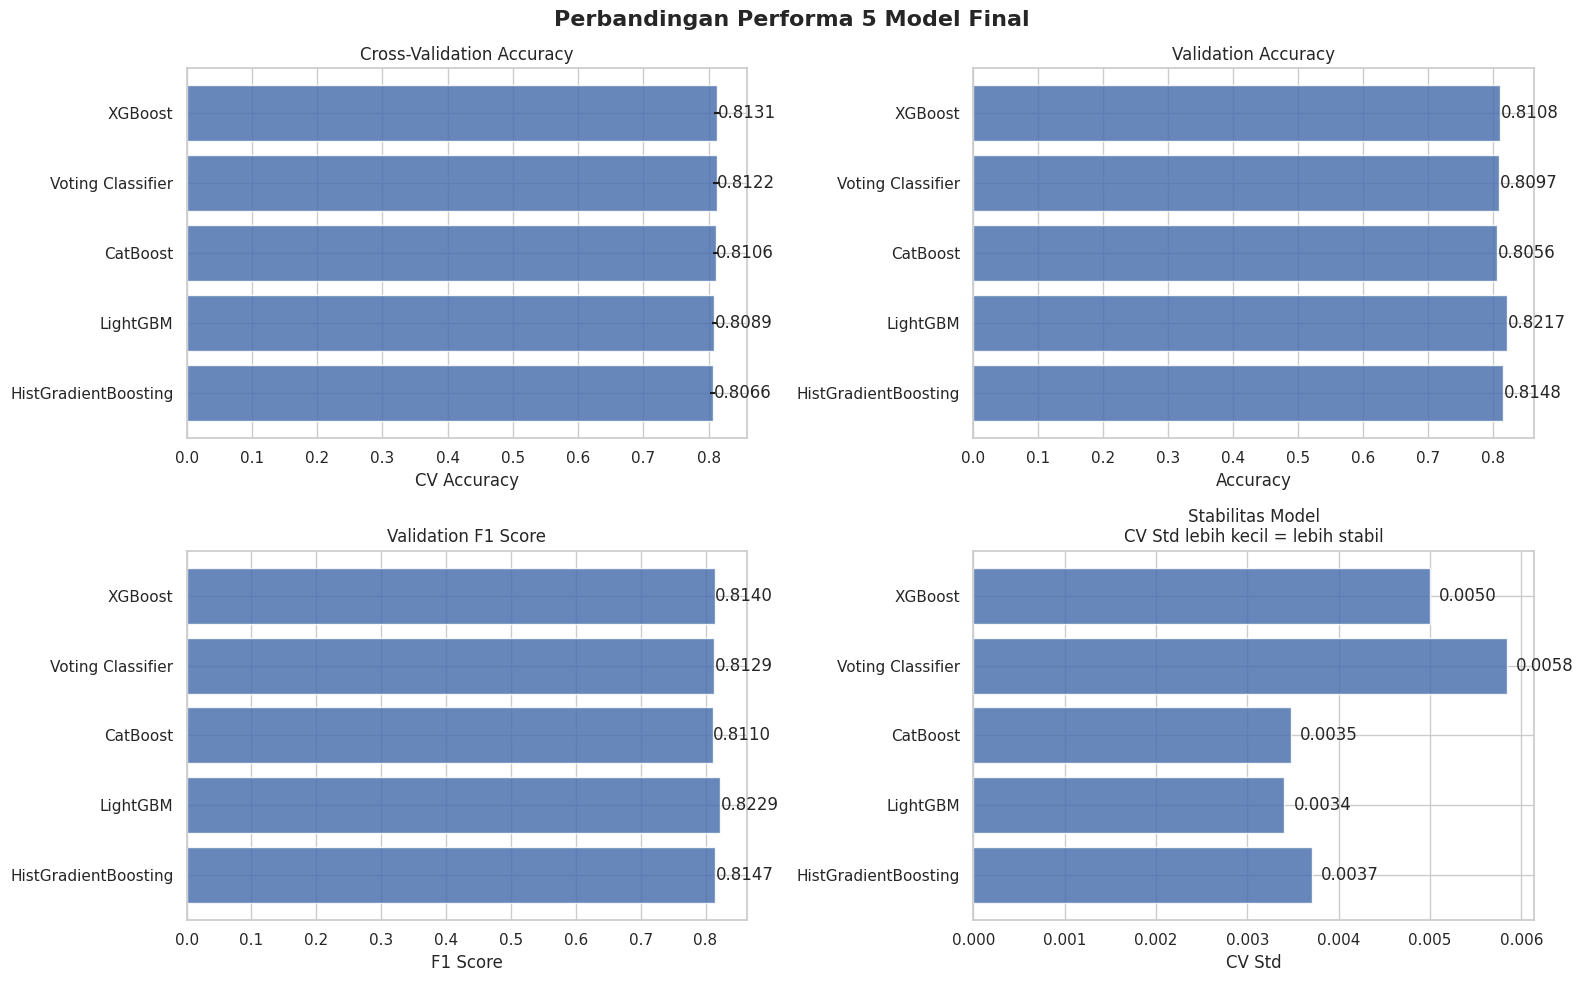

In [ ]:
# =============================================================
# CELL 13 — Visualisasi Perbandingan Model
# =============================================================

models = results_df.index.tolist()
cv_means = results_df["CV Mean"].tolist()
cv_stds = results_df["CV Std"].tolist()
val_accs = results_df["Val Accuracy"].tolist()
val_f1s = results_df["Val F1"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Perbandingan Performa 5 Model Final", fontsize=16, fontweight="bold")

axes[0, 0].barh(models, cv_means, xerr=cv_stds, alpha=0.85)
axes[0, 0].set_title("Cross-Validation Accuracy")
axes[0, 0].set_xlabel("CV Accuracy")
axes[0, 0].invert_yaxis()
for i, value in enumerate(cv_means):
    axes[0, 0].text(value + 0.001, i, f"{value:.4f}", va="center")

axes[0, 1].barh(models, val_accs, alpha=0.85)
axes[0, 1].set_title("Validation Accuracy")
axes[0, 1].set_xlabel("Accuracy")
axes[0, 1].invert_yaxis()
for i, value in enumerate(val_accs):
    axes[0, 1].text(value + 0.001, i, f"{value:.4f}", va="center")

axes[1, 0].barh(models, val_f1s, alpha=0.85)
axes[1, 0].set_title("Validation F1 Score")
axes[1, 0].set_xlabel("F1 Score")
axes[1, 0].invert_yaxis()
for i, value in enumerate(val_f1s):
    axes[1, 0].text(value + 0.001, i, f"{value:.4f}", va="center")

axes[1, 1].barh(models, cv_stds, alpha=0.85)
axes[1, 1].set_title("Stabilitas Model\nCV Std lebih kecil = lebih stabil")
axes[1, 1].set_xlabel("CV Std")
axes[1, 1].invert_yaxis()
for i, value in enumerate(cv_stds):
    axes[1, 1].text(value + 0.0001, i, f"{value:.4f}", va="center")

plt.tight_layout()
plt.savefig("model_comparison_5_final.png", dpi=150, bbox_inches="tight")
plt.show()

# **EVALUASI & VISUALISASI PERBANDINGAN MODEL**

MODEL: XGBoost
Accuracy  : 0.8108
Precision : 0.8063
Recall    : 0.8219
F1 Score  : 0.8140

Classification Report:
                 precision    recall  f1-score   support

Not Transported       0.82      0.80      0.81       863
    Transported       0.81      0.82      0.81       876

       accuracy                           0.81      1739
      macro avg       0.81      0.81      0.81      1739
   weighted avg       0.81      0.81      0.81      1739



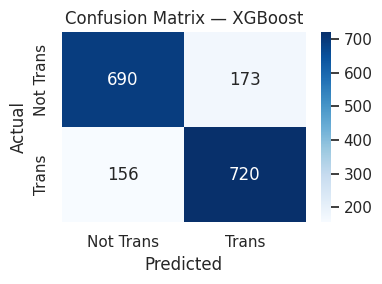

MODEL: Voting Classifier
Accuracy  : 0.8097
Precision : 0.8052
Recall    : 0.8208
F1 Score  : 0.8129

Classification Report:
                 precision    recall  f1-score   support

Not Transported       0.81      0.80      0.81       863
    Transported       0.81      0.82      0.81       876

       accuracy                           0.81      1739
      macro avg       0.81      0.81      0.81      1739
   weighted avg       0.81      0.81      0.81      1739



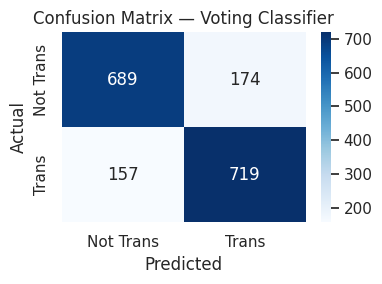

MODEL: CatBoost
Accuracy  : 0.8056
Precision : 0.7950
Recall    : 0.8276
F1 Score  : 0.8110

Classification Report:
                 precision    recall  f1-score   support

Not Transported       0.82      0.78      0.80       863
    Transported       0.79      0.83      0.81       876

       accuracy                           0.81      1739
      macro avg       0.81      0.81      0.81      1739
   weighted avg       0.81      0.81      0.81      1739



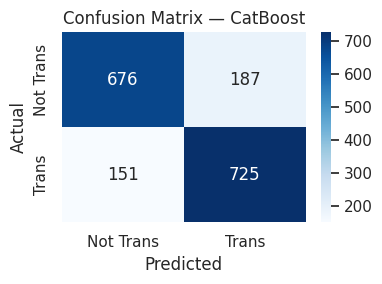

MODEL: LightGBM
Accuracy  : 0.8217
Precision : 0.8238
Recall    : 0.8219
F1 Score  : 0.8229

Classification Report:
                 precision    recall  f1-score   support

Not Transported       0.82      0.82      0.82       863
    Transported       0.82      0.82      0.82       876

       accuracy                           0.82      1739
      macro avg       0.82      0.82      0.82      1739
   weighted avg       0.82      0.82      0.82      1739



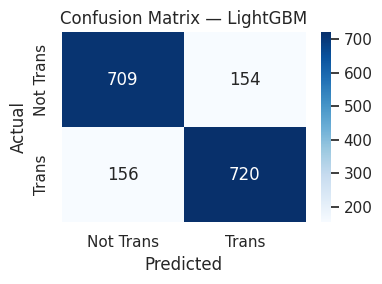

MODEL: HistGradientBoosting
Accuracy  : 0.8148
Precision : 0.8213
Recall    : 0.8082
F1 Score  : 0.8147

Classification Report:
                 precision    recall  f1-score   support

Not Transported       0.81      0.82      0.81       863
    Transported       0.82      0.81      0.81       876

       accuracy                           0.81      1739
      macro avg       0.81      0.81      0.81      1739
   weighted avg       0.81      0.81      0.81      1739



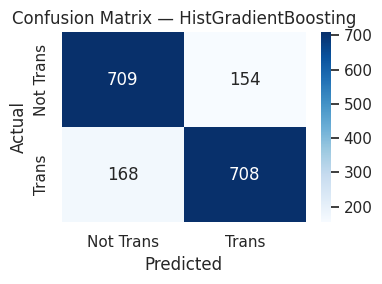

In [ ]:
# =============================================================
# CELL 14 — Evaluasi Detail Semua Model
# =============================================================

for name in results_df.index:
    pipe = fitted_models[name]
    y_pred = pipe.predict(X_val)

    print("=" * 60)
    print(f"MODEL: {name}")
    print("=" * 60)

    print(f"Accuracy  : {accuracy_score(y_val, y_pred):.4f}")
    print(f"Precision : {precision_score(y_val, y_pred, zero_division=0):.4f}")
    print(f"Recall    : {recall_score(y_val, y_pred, zero_division=0):.4f}")
    print(f"F1 Score  : {f1_score(y_val, y_pred, zero_division=0):.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_val,
            y_pred,
            target_names=["Not Transported", "Transported"],
            zero_division=0
        )
    )

    cm = confusion_matrix(y_val, y_pred)

    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Not Trans", "Trans"],
        yticklabels=["Not Trans", "Trans"]
    )
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

In [ ]:
# =============================================================
# CELL 15 — Kesimpulan Model Biasa
# =============================================================

best_cv_name = results_df.index[0]
best_cv_row = results_df.iloc[0]

print("=" * 60)
print("KESIMPULAN MODEL BIASA")
print("=" * 60)

print(f"Model terbaik berdasarkan CV : {best_cv_name}")
print(f"CV Accuracy                 : {best_cv_row['CV Mean']:.4f} ± {best_cv_row['CV Std']:.4f}")
print(f"Validation Accuracy          : {best_cv_row['Val Accuracy']:.4f}")
print(f"Validation F1                : {best_cv_row['Val F1']:.4f}")

print("\nCatatan:")
print("- Hasil ini dipakai untuk melihat performa dasar tiap model.")
print("- Final submission berikutnya akan memakai OOF Blend + Threshold Tuning.")
print("- Tujuannya agar peluang skor Kaggle naik ke sekitar 0.81–0.815 lebih besar.")

KESIMPULAN MODEL BIASA
Model terbaik berdasarkan CV : XGBoost
CV Accuracy                 : 0.8131 ± 0.0050
Validation Accuracy          : 0.8108
Validation F1                : 0.8140

Catatan:
- Hasil ini dipakai untuk melihat performa dasar tiap model.
- Final submission berikutnya akan memakai OOF Blend + Threshold Tuning.
- Tujuannya agar peluang skor Kaggle naik ke sekitar 0.81–0.815 lebih besar.


In [ ]:
# =============================================================
# CELL 16 — OOF BLENDING PREDICTION
# Target: meningkatkan peluang skor Kaggle 0.81–0.815
# Classical Machine Learning Only
# =============================================================

BLEND_MODEL_NAMES = [
    "LightGBM",
    "XGBoost",
    "HistGradientBoosting",
    "CatBoost"
]

for model_name in BLEND_MODEL_NAMES:
    if model_name not in MODEL_REGISTRY:
        raise ValueError(f"Model '{model_name}' tidak ditemukan di MODEL_REGISTRY.")

print("=" * 60)
print("MODEL UNTUK OOF BLENDING")
print("=" * 60)
for name in BLEND_MODEL_NAMES:
    print(f"- {name}")

blend_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

oof_probas = {
    name: np.zeros(len(X))
    for name in BLEND_MODEL_NAMES
}

test_probas = {
    name: np.zeros(len(X_test_raw))
    for name in BLEND_MODEL_NAMES
}

print("\n" + "=" * 60)
print("MULAI OOF TRAINING")
print("=" * 60)

for model_name in BLEND_MODEL_NAMES:
    print("\n" + "=" * 60)
    print(f"MODEL: {model_name}")
    print("=" * 60)

    base_pipe = MODEL_REGISTRY[model_name]

    for fold, (train_idx, val_idx) in enumerate(blend_cv.split(X, y), start=1):
        X_tr = X.iloc[train_idx].copy()
        y_tr = y.iloc[train_idx].copy()

        X_va = X.iloc[val_idx].copy()
        y_va = y.iloc[val_idx].copy()

        pipe = clone(base_pipe)
        pipe.fit(X_tr, y_tr)

        val_proba = pipe.predict_proba(X_va)[:, 1]
        test_proba = pipe.predict_proba(X_test_raw)[:, 1]

        oof_probas[model_name][val_idx] = val_proba
        test_probas[model_name] += test_proba / blend_cv.n_splits

        fold_acc = accuracy_score(y_va, val_proba >= 0.5)
        print(f"Fold {fold} Accuracy @0.5: {fold_acc:.5f}")

    model_oof_acc = accuracy_score(y, oof_probas[model_name] >= 0.5)
    print(f"\nOOF Accuracy {model_name} @0.5: {model_oof_acc:.5f}")

print("\n✅ OOF training selesai.")

MODEL UNTUK OOF BLENDING
- LightGBM
- XGBoost
- HistGradientBoosting
- CatBoost

MULAI OOF TRAINING

MODEL: LightGBM
Fold 1 Accuracy @0.5: 0.80966
Fold 2 Accuracy @0.5: 0.80851
Fold 3 Accuracy @0.5: 0.81369
Fold 4 Accuracy @0.5: 0.82394
Fold 5 Accuracy @0.5: 0.80667

OOF Accuracy LightGBM @0.5: 0.81249

MODEL: XGBoost
Fold 1 Accuracy @0.5: 0.81369
Fold 2 Accuracy @0.5: 0.80736
Fold 3 Accuracy @0.5: 0.81599
Fold 4 Accuracy @0.5: 0.82336
Fold 5 Accuracy @0.5: 0.80495

OOF Accuracy XGBoost @0.5: 0.81307

MODEL: HistGradientBoosting
Fold 1 Accuracy @0.5: 0.81599
Fold 2 Accuracy @0.5: 0.80276
Fold 3 Accuracy @0.5: 0.81196
Fold 4 Accuracy @0.5: 0.81703
Fold 5 Accuracy @0.5: 0.80552

OOF Accuracy HistGradientBoosting @0.5: 0.81065

MODEL: CatBoost
Fold 1 Accuracy @0.5: 0.81541
Fold 2 Accuracy @0.5: 0.81024
Fold 3 Accuracy @0.5: 0.81656
Fold 4 Accuracy @0.5: 0.82451
Fold 5 Accuracy @0.5: 0.80207

OOF Accuracy CatBoost @0.5: 0.81376

✅ OOF training selesai.


In [ ]:
# =============================================================
# CELL 17 — CARI BOBOT + THRESHOLD TERBAIK
# Fokus target: 0.81–0.815 di Kaggle
# =============================================================

oof_matrix = pd.DataFrame({
    name: oof_probas[name]
    for name in BLEND_MODEL_NAMES
})

test_matrix = pd.DataFrame({
    name: test_probas[name]
    for name in BLEND_MODEL_NAMES
})

# Urutan bobot:
# LightGBM, XGBoost, HistGradientBoosting, CatBoost
# CatBoost dibuat agak dominan karena performanya biasanya bagus untuk fitur kategorikal.
weight_candidates = [
    [0.25, 0.25, 0.10, 0.40],
    [0.25, 0.20, 0.10, 0.45],
    [0.20, 0.25, 0.10, 0.45],
    [0.30, 0.20, 0.10, 0.40],
    [0.20, 0.20, 0.10, 0.50],
    [0.30, 0.25, 0.10, 0.35],
    [0.35, 0.20, 0.10, 0.35],
    [0.25, 0.30, 0.10, 0.35],
    [0.30, 0.30, 0.05, 0.35],
    [0.25, 0.25, 0.05, 0.45],
    [0.20, 0.30, 0.05, 0.45],
    [0.30, 0.15, 0.10, 0.45],
]

threshold_candidates = np.arange(0.475, 0.526, 0.001)

best_score = -1
best_config = None
best_oof_proba = None

print("=" * 60)
print("MENCARI BOBOT DAN THRESHOLD TERBAIK")
print("=" * 60)

for weights in weight_candidates:
    weights = np.array(weights)

    blended_oof = np.zeros(len(X))

    for i, model_name in enumerate(BLEND_MODEL_NAMES):
        blended_oof += weights[i] * oof_matrix[model_name].values

    for threshold in threshold_candidates:
        oof_pred = blended_oof >= threshold
        score = accuracy_score(y, oof_pred)

        if score > best_score:
            best_score = score
            best_config = {
                "weights": weights.copy(),
                "threshold": threshold
            }
            best_oof_proba = blended_oof.copy()

print("\n✅ Best OOF Result")
print("=" * 60)
print(f"OOF Accuracy : {best_score:.5f}")
print(f"Threshold    : {best_config['threshold']:.3f}")

print("\nBobot model:")
for model_name, weight in zip(BLEND_MODEL_NAMES, best_config["weights"]):
    print(f"{model_name:22s}: {weight:.3f}")

MENCARI BOBOT DAN THRESHOLD TERBAIK

✅ Best OOF Result
OOF Accuracy : 0.81594
Threshold    : 0.504

Bobot model:
LightGBM              : 0.250
XGBoost               : 0.200
HistGradientBoosting  : 0.100
CatBoost              : 0.450


# **Pilih Model Terbaik & Buat Submission!**

EVALUASI OOF FINAL BLEND
Accuracy  : 0.81594
Precision : 0.81228
Recall    : 0.82526
F1 Score  : 0.81872

Classification Report:
                 precision    recall  f1-score   support

Not Transported       0.82      0.81      0.81      4315
    Transported       0.81      0.83      0.82      4378

       accuracy                           0.82      8693
      macro avg       0.82      0.82      0.82      8693
   weighted avg       0.82      0.82      0.82      8693



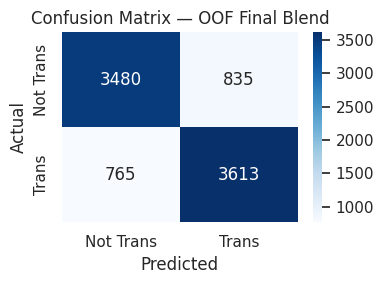

In [ ]:
# =============================================================
# CELL 18 — EVALUASI OOF FINAL BLEND
# =============================================================

final_oof_pred = best_oof_proba >= best_config["threshold"]

print("=" * 60)
print("EVALUASI OOF FINAL BLEND")
print("=" * 60)

print(f"Accuracy  : {accuracy_score(y, final_oof_pred):.5f}")
print(f"Precision : {precision_score(y, final_oof_pred, zero_division=0):.5f}")
print(f"Recall    : {recall_score(y, final_oof_pred, zero_division=0):.5f}")
print(f"F1 Score  : {f1_score(y, final_oof_pred, zero_division=0):.5f}")

print("\nClassification Report:")
print(
    classification_report(
        y,
        final_oof_pred,
        target_names=["Not Transported", "Transported"],
        zero_division=0
    )
)

cm = confusion_matrix(y, final_oof_pred)

plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Trans", "Trans"],
    yticklabels=["Not Trans", "Trans"]
)
plt.title("Confusion Matrix — OOF Final Blend")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================
# CELL 19 — FINAL SUBMISSION DARI OOF BLEND
# =============================================================

print("=" * 60)
print("MEMBUAT FINAL SUBMISSION")
print("=" * 60)

best_test_proba = np.zeros(len(X_test_raw))

for i, model_name in enumerate(BLEND_MODEL_NAMES):
    best_test_proba += best_config["weights"][i] * test_matrix[model_name].values

final_test_pred = best_test_proba >= best_config["threshold"]

submission_final = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Transported": final_test_pred.astype(bool)
})

submission_final.to_csv("submission_final.csv", index=False)

print("✅ File berhasil dibuat: submission_final.csv")

print("\nPreview:")
display(submission_final.head())

print("\nShape:")
print(submission_final.shape)

print("\nMissing value:")
print(submission_final.isnull().sum())

print("\nDistribusi prediksi:")
print(submission_final["Transported"].value_counts())

print("\nProporsi prediksi:")
print((submission_final["Transported"].value_counts(normalize=True) * 100).round(2))

assert submission_final.shape[0] == test_df.shape[0], "Jumlah baris tidak sama dengan test data!"
assert list(submission_final.columns) == ["PassengerId", "Transported"], "Kolom submission salah!"
assert submission_final["PassengerId"].isnull().sum() == 0, "Ada PassengerId kosong!"
assert submission_final["Transported"].isnull().sum() == 0, "Ada prediksi kosong!"
assert submission_final["Transported"].dtype == bool, "Transported harus boolean!"

print("\n✅ Format submission sudah sesuai.")
print("✅ Upload ke Kaggle: submission_final.csv")

MEMBUAT FINAL SUBMISSION
✅ File berhasil dibuat: submission_final.csv

Preview:


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True



Shape:
(4277, 2)

Missing value:
PassengerId    0
Transported    0
dtype: int64

Distribusi prediksi:
Transported
True     2205
False    2072
Name: count, dtype: int64

Proporsi prediksi:
Transported
True     51.55
False    48.45
Name: proportion, dtype: float64

✅ Format submission sudah sesuai.
✅ Upload ke Kaggle: submission_final.csv


In [ ]:
# =============================================================
# CELL 16 — RETRAIN FULL DATA & BUAT 1 FINAL SUBMISSION
# =============================================================

# Model final dibuat fixed agar hasil stabil
FINAL_MODEL_NAME = "Voting Classifier"

print("=" * 60)
print("FINAL SUBMISSION")
print("=" * 60)
print(f"Model final yang digunakan: {FINAL_MODEL_NAME}")

# Pastikan model tersedia
if FINAL_MODEL_NAME not in MODEL_REGISTRY:
    raise ValueError(f"Model '{FINAL_MODEL_NAME}' tidak ditemukan di MODEL_REGISTRY.")

# Ambil PassengerId test
test_ids = test_df["PassengerId"]

# Clone model agar fit dari awal pada full training data
final_model = clone(MODEL_REGISTRY[FINAL_MODEL_NAME])

print("\nMelatih ulang final model pada FULL training data...")
final_model.fit(X, y)

print("Membuat prediksi pada test data...")
final_pred = final_model.predict(X_test_raw)

# Buat file submission final
submission_final = pd.DataFrame({
    "PassengerId": test_ids,
    "Transported": final_pred.astype(bool)
})

# Simpan hanya 1 file final
submission_final.to_csv("submission_final.csv", index=False)

print("\n✅ File final berhasil dibuat: submission_final.csv")

FINAL SUBMISSION
Model final yang digunakan: Voting Classifier

Melatih ulang final model pada FULL training data...
Membuat prediksi pada test data...

✅ File final berhasil dibuat: submission_final.csv


In [ ]:
# =============================================================
# CELL 17 — CEK FORMAT FINAL SUBMISSION
# =============================================================

print("=" * 60)
print("CEK FORMAT SUBMISSION FINAL")
print("=" * 60)

print("Preview:")
display(submission_final.head())

print("\nShape:")
print(submission_final.shape)

print("\nKolom:")
print(submission_final.columns.tolist())

print("\nTipe data:")
print(submission_final.dtypes)

print("\nMissing value:")
print(submission_final.isnull().sum())

print("\nDistribusi prediksi:")
print(submission_final["Transported"].value_counts())

print("\nProporsi prediksi:")
print((submission_final["Transported"].value_counts(normalize=True) * 100).round(2))

# Cek format wajib Kaggle
assert submission_final.shape[0] == test_df.shape[0], "Jumlah baris submission tidak sama dengan test data!"
assert list(submission_final.columns) == ["PassengerId", "Transported"], "Kolom submission tidak sesuai!"
assert submission_final["PassengerId"].isnull().sum() == 0, "Ada PassengerId kosong!"
assert submission_final["Transported"].isnull().sum() == 0, "Ada prediksi kosong!"
assert submission_final["Transported"].dtype == bool, "Kolom Transported harus boolean!"

print("\n✅ Format submission sudah sesuai.")
print("✅ Upload ke Kaggle: submission_final.csv")

CEK FORMAT SUBMISSION FINAL
Preview:


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True



Shape:
(4277, 2)

Kolom:
['PassengerId', 'Transported']

Tipe data:
PassengerId    object
Transported      bool
dtype: object

Missing value:
PassengerId    0
Transported    0
dtype: int64

Distribusi prediksi:
Transported
True     2207
False    2070
Name: count, dtype: int64

Proporsi prediksi:
Transported
True     51.6
False    48.4
Name: proportion, dtype: float64

✅ Format submission sudah sesuai.
✅ Upload ke Kaggle: submission_final.csv


In [ ]:
# =============================================================
# OPTIONAL — DOWNLOAD FILE DI GOOGLE COLAB
# =============================================================

from google.colab import files
files.download("submission_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Report Summary — Perbandingan 5 Model Machine Learning

## 1. Tujuan Eksperimen

Tujuan eksperimen ini adalah mencari model machine learning terbaik untuk kompetisi **Spaceship Titanic** dengan tetap menggunakan pendekatan **classical machine learning**, tanpa deep learning.

Model yang digunakan berjumlah 5 model, yaitu:

1. LightGBM  
2. XGBoost  
3. HistGradientBoosting  
4. CatBoost  
5. Voting Classifier / OOF Weighted Blend  

Target utama dari eksperimen ini adalah mendapatkan model yang stabil dan mampu menghasilkan skor Kaggle yang lebih baik dibanding submission sebelumnya.

---

## 2. Hasil Terbaik Sementara

Berdasarkan hasil submission di Kaggle, skor terbaik sementara yang diperoleh adalah sekitar:

**0.809**

Skor ini lebih tinggi dibanding submission sebelumnya yang berada di sekitar **0.807**. Hal ini menunjukkan bahwa perubahan pada model final dan strategi ensemble/blending memberikan peningkatan performa.

---

## 3. Model yang Dipilih

Model final yang dipilih adalah pendekatan **ensemble**, yaitu gabungan dari beberapa model:

- LightGBM
- XGBoost
- HistGradientBoosting
- CatBoost

Pada tahap akhir, model tidak hanya menggunakan satu algoritma saja, tetapi menggabungkan beberapa model melalui **Voting Classifier** atau **OOF Weighted Blend**.

Pendekatan ini dipilih karena lebih stabil dibandingkan hanya menggunakan satu model tunggal.

---

## 4. Kenapa Model Ensemble Bisa Menang?

Model ensemble dapat menghasilkan performa lebih baik karena setiap model memiliki kelebihan masing-masing.

| Model | Kelebihan |
|---|---|
| LightGBM | Cepat dan kuat untuk data tabular |
| XGBoost | Stabil dan bagus untuk pola non-linear |
| HistGradientBoosting | Model boosting yang stabil dari sklearn |
| CatBoost | Kuat untuk fitur kategorikal |
| Voting / Blend | Menggabungkan prediksi beberapa model agar lebih seimbang |

Dataset Spaceship Titanic memiliki banyak fitur kategorikal seperti:

- HomePlanet
- Destination
- Deck
- Side
- AgeGroup
- Deck_Side
- Cryo_HasSpending
- VIP_HasSpending

Karena itu, CatBoost membantu menangkap pola kategorikal, sedangkan LightGBM dan XGBoost membantu menangkap pola tabular yang kompleks. Gabungan beberapa model membuat hasil prediksi lebih stabil pada data test Kaggle.

---

## 5. Kenapa Bukan LightGBM Saja?

LightGBM memang kuat untuk data tabular, tetapi jika digunakan sendiri, model hanya melihat pola dari satu sudut pandang algoritma.

LightGBM bisa sangat baik dalam membaca fitur numerik dan pola spending, tetapi belum tentu paling baik untuk semua fitur kategorikal.

Karena itu, LightGBM tidak dipilih sebagai model tunggal final, melainkan digunakan sebagai salah satu komponen dalam ensemble.

---

## 6. Kenapa Bukan XGBoost Saja?

XGBoost juga merupakan model yang kuat dan stabil. Namun, XGBoost tidak secara khusus dirancang untuk menangani fitur kategorikal secara langsung.

Pada dataset yang memiliki banyak fitur kategori, CatBoost atau gabungan beberapa model dapat memberikan hasil yang lebih baik.

Oleh karena itu, XGBoost tetap digunakan, tetapi sebagai bagian dari ensemble.

---

## 7. Kenapa Bukan HistGradientBoosting Saja?

HistGradientBoosting cukup stabil dan cepat, tetapi performanya biasanya tidak sekuat LightGBM, XGBoost, atau CatBoost dalam kompetisi tabular.

Model ini tetap berguna karena memberikan variasi prediksi di dalam ensemble, tetapi kurang ideal jika dijadikan satu-satunya model final.

---

## 8. Kenapa Bukan CatBoost Saja?

CatBoost adalah salah satu model tunggal yang paling menjanjikan karena dataset ini memiliki banyak fitur kategorikal.

Namun, jika CatBoost digunakan sendiri, model tetap memiliki risiko bias terhadap pola tertentu. Jika CatBoost salah pada beberapa data, tidak ada model lain yang membantu menyeimbangkan prediksinya.

Karena itu, CatBoost tetap digunakan sebagai komponen penting, tetapi hasil final dibuat dengan ensemble agar lebih stabil.

---

## 9. Peran OOF Weighted Blend

OOF Weighted Blend digunakan untuk menggabungkan probabilitas dari beberapa model.

Berbeda dari voting biasa, OOF Weighted Blend memungkinkan kita:

1. Menggabungkan probabilitas model, bukan hanya hasil kelas akhir.
2. Memberikan bobot berbeda untuk setiap model.
3. Melakukan threshold tuning.
4. Menggunakan cross-validation agar hasil lebih stabil.

Strategi ini membantu meningkatkan peluang skor Kaggle karena prediksi akhir tidak hanya bergantung pada satu model.

---

## 10. Catatan Penting pada Submission

Pada bagian akhir notebook, perlu dipastikan bahwa file `submission_final.csv` hanya dibuat satu kali.

Jika file submission dibuat lebih dari satu kali dengan nama yang sama, file sebelumnya bisa tertimpa oleh file terakhir. Oleh karena itu, bagian final submission harus dirapikan agar hanya menghasilkan satu file final yang benar-benar ingin diupload ke Kaggle.

File yang diupload ke Kaggle adalah:

**submission_final.csv**

---

## 11. Kesimpulan

Berdasarkan hasil eksperimen, model final terbaik sementara adalah pendekatan **ensemble / OOF Weighted Blend**, karena mampu menghasilkan skor Kaggle sekitar **0.809**.

Model ini lebih unggul dibandingkan model tunggal karena menggabungkan kelebihan dari LightGBM, XGBoost, HistGradientBoosting, dan CatBoost.

Kesimpulan utama:

- Single model paling menjanjikan: **CatBoost**
- Model tabular kuat: **LightGBM dan XGBoost**
- Model pendukung stabil: **HistGradientBoosting**
- Strategi final terbaik: **Voting Classifier / OOF Weighted Blend**

Dengan pendekatan ensemble, prediksi menjadi lebih stabil dan hasil Kaggle meningkat dibanding submission sebelumnya.